In [6]:
! pip install -U SpatialDM

In [8]:
! pip install pandas==1.5.3

     |████████████████████████████████| 12.2 MB 16.6 MB/s eta 0:00:01
  Attempting uninstall: pandas
    Found existing installation: pandas 2.0.2
    Uninstalling pandas-2.0.2:
      Successfully uninstalled pandas-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch-geometric 2.0.3 requires rdflib, which is not installed.
xfuse 0.2.1 requires click<8.0.0,>=7.1.2, but you have click 8.0.3 which is incompatible.
xfuse 0.2.1 requires Pillow<9.0.0,>=8.0.1, but you have pillow 9.5.0 which is incompatible.
xfuse 0.2.1 requires scikit-learn<0.25.0,>=0.24.2, but you have scikit-learn 1.0.1 which is incompatible.
xfuse 0.2.1 requires tifffile<2021.0.0,>=2020.10.1, but you have tifffile 2023.4.12 which is incompatible.
xfuse 0.2.1 requires torchvision<0.10.0,>=0.9.1, but you have torchvision 0.11.2 which is incompatible.


# Step 1

In [10]:
# create adata for cell abundance ground truth

import pandas as pd
import numpy as np
import anndata as ad
from scipy.sparse import csr_matrix

spot_coord = pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/WSA_LngSP8759312/spots.csv", index_col=0)
spot_coord['X'] = spot_coord['X']
spot_coord['Y'] = spot_coord['Y']

cell_abundance = pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/WSA_LngSP8759312/cell_ratio.csv", index_col=0)
cell_abundance = cell_abundance.loc[spot_coord.index]

location = np.matrix(spot_coord.values)
Xdense = np.matrix(cell_abundance.values)

X = csr_matrix(Xdense, dtype=np.float32)
adata = ad.AnnData(X, obsm={"spatial": spot_coord.values})
adata.obs_names = list(cell_abundance.index)
adata.var_names = list(cell_abundance.columns)
adata

AnnData object with n_obs × n_vars = 2564 × 80
    obsm: 'spatial'

In [8]:
type(spot_coord.values)

numpy.ndarray

/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/scipy/sparse/_compressed.py:290: SparseEfficiencyWarning: Comparing a sparse matrix with a scalar greater than zero using < is inefficient, try using >= instead.
  warn(bad_scalar_msg, SparseEfficiencyWarning)
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


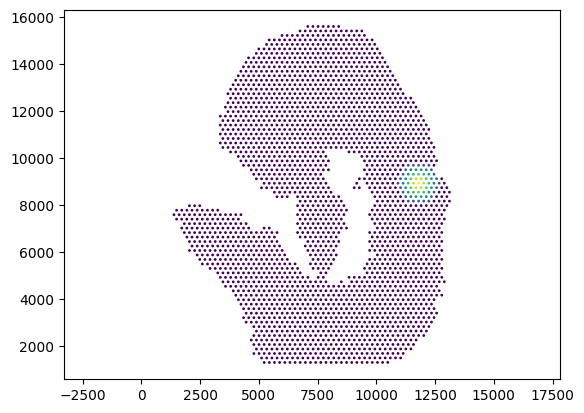

In [13]:
# create sptial weight matrix for cell abundance ground truth

import spatialdm as sdm
import matplotlib.pyplot as plt

sdm.weight_matrix(adata, l=500, cutoff=0.2, single_cell=False) # weight_matrix by rbf kernel
plt.scatter(list(adata.obsm['spatial'][:,0]), list(adata.obsm['spatial'][:,1]),
            c=adata.obsp['weight'].A[50], s=1.0)
plt.axis('equal')
plt.show()

In [18]:
# define moran's R calculation function

from scipy.sparse import csc_matrix, csr_matrix, issparse, hstack
from scipy import stats

# pure statistics for bivariate Moran's R
def Moran_R_std(spatial_W, by_trace=False):
    """Calculate standard deviation of Moran's R under the null distribution.
    """
    N = spatial_W.shape[0]

    if by_trace:
        W = spatial_W.copy()
        H = np.identity(N) - np.ones((N, N)) / N
        HWH = H.dot(W.dot(H))
        var = np.trace(HWH.dot(HWH)) * N**2 / (np.sum(W) * (N-1))**2
    else:
        if issparse(spatial_W):
            nm = N ** 2 * spatial_W.multiply(spatial_W.T).sum() \
                - 2 * N * (spatial_W.sum(0) @ spatial_W.sum(1)).sum() \
                + spatial_W.sum() ** 2
        else:
            nm = N ** 2 * (spatial_W * spatial_W.T).sum() \
                - 2 * N * (spatial_W.sum(1) * spatial_W.sum(0)).sum() \
                + spatial_W.sum() ** 2
        dm = N ** 2 * (N - 1) ** 2
        var = nm / dm

    return np.sqrt(var)


def Moran_R(X, Y, spatial_W, standardise=True, nproc=1):
    """Computing Moran's R for pairs of variables
    
    :param X: Variable 1, (n_sample, n_variables) or (n_sample, )
    :param Y: Variable 2, (n_sample, n_variables) or (n_sample, )
    :param spatial_W: spatial weight matrix, sparse or dense, (n_sample, n_sample)
    :param nproc: default to 1. Numpy may use more without much speedup.
    
    :return: (Moran's R, z score and p values)
    """
    if len(X.shape) < 2:
        X = X.reshape(-1, 1)
    if len(Y.shape) < 2:
        Y = Y.reshape(-1, 1)

    if standardise:
        X = (X - np.mean(X, axis=0, keepdims=True)) / np.std(X, axis=0, keepdims=True)
        Y = (Y - np.mean(Y, axis=0, keepdims=True)) / np.std(Y, axis=0, keepdims=True)

    # Consider to dense array for speedup (numpy's codes is optimised)
    if X.shape[0] <= 5000 and issparse(spatial_W):
        # Note, numpy may use unnessary too many threads
        # You may use threadpool.threadpool_limits() outside
        from threadpoolctl import threadpool_limits

        with threadpool_limits(limits=nproc, user_api='blas'):
            R_val = (spatial_W.A @ X * Y).sum(axis=0) / np.sum(spatial_W)
    else:
        # we assume it's sparse spatial_W when sample size > 5000
        R_val = (spatial_W @ X * Y).sum(axis=0) / np.sum(spatial_W)

    _R_std = Moran_R_std(spatial_W)
    R_z_score = R_val / _R_std
    R_p_val = stats.norm.sf(R_z_score)

    return R_val, R_z_score, R_p_val

In [16]:
# get all cell type pair combinations

import os

cell_names = list(pd.read_csv(os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location/WSA_LngSP8759312/cell_ratio.csv")).columns)[1:]
combinations = []

for i in range(len(cell_names)):
    for j in range(i+1, len(cell_names)):
        combinations.append((cell_names[i], cell_names[j]))

len(combinations)

3160

In [5]:
# calculate moran's R for all cell type pairs

from tqdm import tqdm

df = pd.DataFrame(columns=['A', 'B', 'R_val', 'R_z_score', 'R_p_val'])
for pair in tqdm(combinations):
    X = adata[:, pair[0]].X.A
    Y = adata[:, pair[1]].X.A
    R_val, R_z_score, R_p_val = Moran_R(X, Y, adata.obsp['weight'])
    df.loc[len(df)] = [pair[0], pair[1], R_val[0], R_z_score[0], R_p_val[0]]
df

100%|██████████| 3160/3160 [11:38<00:00,  4.52it/s]


,A,B,R_val,R_z_score,R_p_val
0,q05cell_abundance_w_sf_AT1,q05cell_abundance_w_sf_AT2,0.097368,33.211068,3.725992e-242
1,q05cell_abundance_w_sf_AT1,q05cell_abundance_w_sf_B_memory,0.177974,60.704932,0.000000e+00
2,q05cell_abundance_w_sf_AT1,q05cell_abundance_w_sf_B_naive,0.174671,59.578378,0.000000e+00
3,q05cell_abundance_w_sf_AT1,q05cell_abundance_w_sf_B_plasma_IgA,0.081295,27.728761,1.571578e-169
4,q05cell_abundance_w_sf_AT1,q05cell_abundance_w_sf_B_plasma_IgG,0.084338,28.766882,2.785360e-182
...,...,...,...,...,...
3155,q05cell_abundance_w_sf_Secretory_Goblet,q05cell_abundance_w_sf_T_reg,0.351597,119.925912,0.000000e+00
3156,q05cell_abundance_w_sf_Secretory_Goblet,q05cell_abundance_w_sf_gdT,0.285961,97.538192,0.000000e+00
3157,q05cell_abundance_w_sf_Suprabasal,q05cell_abundance_w_sf_T_reg,0.305319,104.141030,0.000000e+00
3158,q05cell_abundance_w_sf_Suprabasal,q05cell_abundance_w_sf_gdT,0.241533,82.384434,0.000000e+00


In [6]:
# sort according to the moran's R score

df_sorted = df.sort_values('R_val', ascending=False)
df_sorted

,A,B,R_val,R_z_score,R_p_val
2339,q05cell_abundance_w_sf_ILC,q05cell_abundance_w_sf_gdT,0.691039,235.705923,0.000000
604,q05cell_abundance_w_sf_CD4_EM_Effector,q05cell_abundance_w_sf_CD4_TRM,0.688187,234.733358,0.000000
633,q05cell_abundance_w_sf_CD4_EM_Effector,q05cell_abundance_w_sf_ILC,0.687616,234.538635,0.000000
703,q05cell_abundance_w_sf_CD4_TRM,q05cell_abundance_w_sf_ILC,0.687588,234.528792,0.000000
674,q05cell_abundance_w_sf_CD4_EM_Effector,q05cell_abundance_w_sf_gdT,0.686309,234.092695,0.000000
...,...,...,...,...,...
1141,q05cell_abundance_w_sf_Chondrocyte,q05cell_abundance_w_sf_Suprabasal,-0.011656,-3.975893,0.999965
1087,q05cell_abundance_w_sf_Chondrocyte,q05cell_abundance_w_sf_Dividing_Basal,-0.012713,-4.336427,0.999993
14,q05cell_abundance_w_sf_AT1,q05cell_abundance_w_sf_Chondrocyte,-0.013459,-4.590698,0.999998
92,q05cell_abundance_w_sf_AT2,q05cell_abundance_w_sf_Chondrocyte,-0.013460,-4.590974,0.999998


In [7]:
# save the cell type pair and its moran's R

df_sorted.to_csv("/data2/r10user3/Spatial_Gene_Cell_Ratio/code/output_csv/cell_pair_from_label.csv")

# Step 2

In [1]:
# load multi-task cell GNN slide predictions

import joblib

slide_pred = joblib.load('/data2/r10user3/Spatial_Gene_Cell_Ratio/code/predictions/cell_gene_2layersimpleGNN_lr1e-4_best_cell_all_abundance_average.pkl')

In [6]:
# crate adata for cell abundance predictions

import pandas as pd
import os

slide = "WSA_LngSP8759312"
spots_coord = pd.read_csv(os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, 'spots.csv'), index_col=0)
cell_names = list(pd.read_csv(os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, 'cell_ratio.csv')).columns)[1:]

preds = slide_pred[slide]['cell_abundance_predictions']

patch_names = slide_pred[slide]['spot_names']
patch_names

['WSA_LngSP8759312_TAGGTTCTGCTGAGAA-1',
 'WSA_LngSP8759312_GCACTAGTCGCGCTAT-1',
 'WSA_LngSP8759312_CAAGCGGCACATAATT-1',
 'WSA_LngSP8759312_ACCAACGCTTATTTAT-1',
 'WSA_LngSP8759312_CTTAGCCCGGATAGTG-1',
 'WSA_LngSP8759312_CCTATGGTCAAAGCTG-1',
 'WSA_LngSP8759312_TGGTTGGAGGATCCTG-1',
 'WSA_LngSP8759312_AATCGCCTCAGCGCCA-1',
 'WSA_LngSP8759312_TTAATCAGTACGTCAG-1',
 'WSA_LngSP8759312_TATATTCGCGTCGATA-1',
 'WSA_LngSP8759312_ACTCCCGAATTCGTTT-1',
 'WSA_LngSP8759312_TGGTGCCCTGCCTTAC-1',
 'WSA_LngSP8759312_AGAAGAGCGCCGTTCC-1',
 'WSA_LngSP8759312_GGGAACGGTTTCAGAT-1',
 'WSA_LngSP8759312_ATGGCAGCCGAGAAAC-1',
 'WSA_LngSP8759312_TCAGGGCGCAAACTCG-1',
 'WSA_LngSP8759312_GGATCAAAGGACGAGG-1',
 'WSA_LngSP8759312_ACGATCATACATAGAG-1',
 'WSA_LngSP8759312_AAGTTCACTCCAAGCT-1',
 'WSA_LngSP8759312_ACAAGCAGTGCCTAGC-1',
 'WSA_LngSP8759312_TAGCGTCCGGTGTGGT-1',
 'WSA_LngSP8759312_TATCACTTCGAGTAAC-1',
 'WSA_LngSP8759312_ACTTACGCATCCACGC-1',
 'WSA_LngSP8759312_CACGTTCGTGCTCTAG-1',
 'WSA_LngSP8759312_AGTACGGCCCGTATCG-1',


In [9]:
spots_coord = spots_coord.loc[patch_names]
spots_coord

,X,Y
spot_id,,
WSA_LngSP8759312_TAGGTTCTGCTGAGAA-1,8065,15032
WSA_LngSP8759312_GCACTAGTCGCGCTAT-1,5990,3781
WSA_LngSP8759312_CAAGCGGCACATAATT-1,9163,11601
WSA_LngSP8759312_ACCAACGCTTATTTAT-1,6643,11409
WSA_LngSP8759312_CTTAGCCCGGATAGTG-1,2262,6449
...,...,...
WSA_LngSP8759312_TTCTGACCGGGCTCAA-1,10478,11220
WSA_LngSP8759312_CGATCGAGAAGCACCA-1,8284,15414
WSA_LngSP8759312_GATGACAAGTAGGGCA-1,4889,12170


In [12]:
cell_abundance.index

Index(['WSA_LngSP8759312_AAACAATCTACTAGCA-1',
       'WSA_LngSP8759312_AAACAGAGCGACTCCT-1',
       'WSA_LngSP8759312_AAACAGTGTTCCTGGG-1',
       'WSA_LngSP8759312_AAACCGTTCGTCCAGG-1',
       'WSA_LngSP8759312_AAACCTAAGCAGCCGG-1',
       'WSA_LngSP8759312_AAACGAAGAACATACC-1',
       'WSA_LngSP8759312_AAACGAGACGGTTGAT-1',
       'WSA_LngSP8759312_AAACGGTTGCGAACTG-1',
       'WSA_LngSP8759312_AAACTCGGTTCGCAAT-1',
       'WSA_LngSP8759312_AAAGACCCAAGTCGCG-1',
       ...
       'WSA_LngSP8759312_TTGTGGCCCTGACAGT-1',
       'WSA_LngSP8759312_TTGTGGTAGGAGGGAT-1',
       'WSA_LngSP8759312_TTGTGTATGCCACCAA-1',
       'WSA_LngSP8759312_TTGTGTTTCCCGAAAG-1',
       'WSA_LngSP8759312_TTGTTAGCAAATTCGA-1',
       'WSA_LngSP8759312_TTGTTCAGTGTGCTAC-1',
       'WSA_LngSP8759312_TTGTTTCACATCCAGG-1',
       'WSA_LngSP8759312_TTGTTTCATTAGTCTA-1',
       'WSA_LngSP8759312_TTGTTTCCATACAACT-1',
       'WSA_LngSP8759312_TTGTTTGTGTAAATTC-1'],
      dtype='object', name='spot_id', length=2564)

In [14]:
location = np.matrix(spots_coord.values)
Xdense = np.matrix(preds)

X = csr_matrix(Xdense, dtype=np.float32)
adata = ad.AnnData(X, obsm={"spatial": location})
adata.obs_names = list(spots_coord.index)
adata.var_names = list(cell_names)
adata

AnnData object with n_obs × n_vars = 2564 × 80
    obsm: 'spatial'

/home/r10user3/anaconda3/envs/pyg/lib/python3.8/site-packages/sklearn/utils/validation.py:585: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
  warnings.warn(
/home/r10user3/anaconda3/envs/pyg/lib/python3.8/site-packages/sklearn/utils/validation.py:585: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
  warnings.warn(
/home/r10user3/anaconda3/envs/pyg/lib/python3.8/site-packages/sklearn/utils/validation.py:585: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix

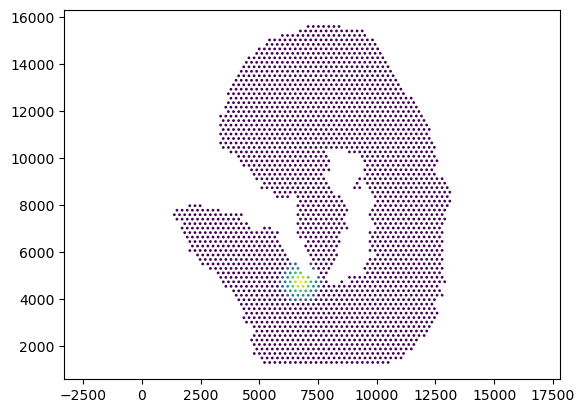

In [15]:
import spatialdm as sdm
import matplotlib.pyplot as plt

sdm.weight_matrix(adata, l=500, cutoff=0.2, single_cell=False) # weight_matrix by rbf kernel
plt.scatter(list(adata.obsm['spatial'][:,0]), list(adata.obsm['spatial'][:,1]),
            c=adata.obsp['weight'].A[50], s=1.0)
plt.axis('equal')
plt.show()

In [19]:
# calculate moran's R for all cell type pairs

from tqdm import tqdm

df = pd.DataFrame(columns=['A', 'B', 'R_val', 'R_z_score', 'R_p_val'])
for pair in tqdm(combinations):
    X = adata[:, pair[0]].X.A
    Y = adata[:, pair[1]].X.A
    R_val, R_z_score, R_p_val = Moran_R(X, Y, adata.obsp['weight'])
    df.loc[len(df)] = [pair[0], pair[1], R_val[0], R_z_score[0], R_p_val[0]]
df

100%|██████████| 3160/3160 [10:36<00:00,  4.96it/s]


,A,B,R_val,R_z_score,R_p_val
0,q05cell_abundance_w_sf_AT1,q05cell_abundance_w_sf_AT2,0.435935,148.692889,0.000000e+00
1,q05cell_abundance_w_sf_AT1,q05cell_abundance_w_sf_B_memory,0.420971,143.588566,0.000000e+00
2,q05cell_abundance_w_sf_AT1,q05cell_abundance_w_sf_B_naive,0.410515,140.022157,0.000000e+00
3,q05cell_abundance_w_sf_AT1,q05cell_abundance_w_sf_B_plasma_IgA,0.255972,87.309368,0.000000e+00
4,q05cell_abundance_w_sf_AT1,q05cell_abundance_w_sf_B_plasma_IgG,0.176214,60.104688,0.000000e+00
...,...,...,...,...,...
3155,q05cell_abundance_w_sf_Secretory_Goblet,q05cell_abundance_w_sf_T_reg,0.154729,52.776364,0.000000e+00
3156,q05cell_abundance_w_sf_Secretory_Goblet,q05cell_abundance_w_sf_gdT,0.096500,32.915188,6.663565e-238
3157,q05cell_abundance_w_sf_Suprabasal,q05cell_abundance_w_sf_T_reg,0.189743,64.719152,0.000000e+00
3158,q05cell_abundance_w_sf_Suprabasal,q05cell_abundance_w_sf_gdT,0.150676,51.393836,0.000000e+00


In [20]:
df_sorted = df.sort_values('R_val', ascending=False)
df_sorted

,A,B,R_val,R_z_score,R_p_val
2324,q05cell_abundance_w_sf_ILC,q05cell_abundance_w_sf_NK_CD16hi,0.613929,209.404677,0.0
3041,q05cell_abundance_w_sf_NK_CD16hi,q05cell_abundance_w_sf_NK_CD11d,0.611113,208.444051,0.0
1001,q05cell_abundance_w_sf_CD8_TRM_EM,q05cell_abundance_w_sf_NK_CD11d,0.607547,207.227707,0.0
868,q05cell_abundance_w_sf_CD8_EM,q05cell_abundance_w_sf_NK_CD11d,0.607039,207.054571,0.0
3116,q05cell_abundance_w_sf_SMG_Duct,q05cell_abundance_w_sf_SMG_Serous,0.606158,206.754098,0.0
...,...,...,...,...,...
1278,q05cell_abundance_w_sf_DC_2,q05cell_abundance_w_sf_Endothelia_vascular_art...,-0.054366,-18.543526,1.0
439,q05cell_abundance_w_sf_B_plasma_IgG,q05cell_abundance_w_sf_Muscle_smooth_syst_arte...,-0.058756,-20.040891,1.0
438,q05cell_abundance_w_sf_B_plasma_IgG,q05cell_abundance_w_sf_Muscle_smooth_pulmonary,-0.060044,-20.480297,1.0
434,q05cell_abundance_w_sf_B_plasma_IgG,q05cell_abundance_w_sf_Muscle_airway,-0.060605,-20.671835,1.0


In [21]:
df_sorted.to_csv("/data2/r10user3/Spatial_Gene_Cell_Ratio/code/output_csv/cell_pair_from_prediction.csv")

# Step 3

In [39]:
# get the common pairs in ground truth and predictions

df1 = pd.read_csv("/data2/r10user3/Spatial_Gene_Cell_Ratio/code/output_csv/cell_pair_from_label.csv", index_col=0)
df2 = pd.read_csv("/data2/r10user3/Spatial_Gene_Cell_Ratio/code/output_csv/cell_pair_from_prediction.csv", index_col=0)
df1 = df1.head(50)
df2 = df2.head(50)


In [40]:
merged_df = pd.merge(df1, df2, on=['A', 'B'], how='inner')
count = merged_df[['A', 'B']].dropna().shape[0]
count

23

In [35]:
merged_df.to_csv("/data2/r10user3/Spatial_Gene_Cell_Ratio/code/output_csv/common_cell_pairs_intop200.csv")